# Excercise 2a: Exploratory Data Analysis

In [2]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
X_train = pd.read_csv("ex2_train.csv")
y_train = pd.read_csv("ex2_class_train.csv")
data = X_train.copy()
data['Survived'] = y_train

In [4]:
data.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,1,"Partner, Mr. Austen",male,45.5,0,0,28.5000,S,0
1,2,"Berriman, Mr. William John",male,23.0,0,0,13.0000,S,0
2,3,"Tikkanen, Mr. Juho",male,32.0,0,0,7.9250,S,0
3,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,7.8542,S,0
4,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,31.2750,S,0


This is a widely used dataset that contains information on the passengers who were aboard the Titanic when it sank on its maiden voyage in 1912. We will use it for a supervised learning exercise (ex2b) to predict whether a passenger can survive based on his or her attributes. Before constructing the classifier, you need to do some guided exploratory data analysis in ex2a.

The column meanings are: 
* Survived: Survival status (0 = No, 1 = Yes).
* Pclass: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd).
* Name: Name of the passenger.
* Sex: Gender of the passenger (male/female).
* Age: Age of the passenger in years.
* SibSp: Number of siblings/spouses aboard the Titanic.
* Parch: Number of parents/children aboard the Titanic.
* Fare: Passenger fare.
* Embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).

**TODO: Please answer the following questions by using suitable analysis tools, e.g. statistics or visualizations.** To pass the exercise, you need to correctly answer three or more of Questions 1 to 5. A correct answer includes a correct statement and the analysis result that support the statement.

# Example Question: Is gender related to survival rate?

Answer: Yes, females had a higher survival rate.

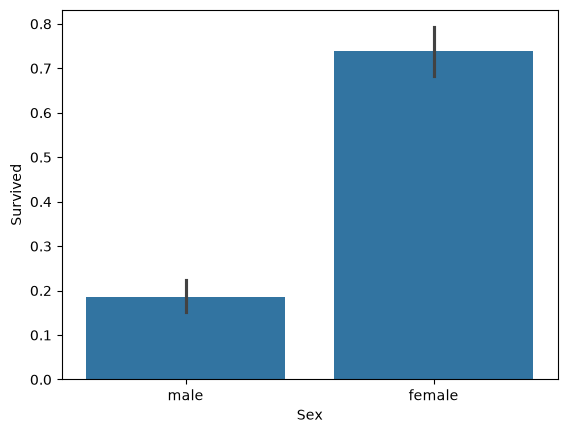

In [6]:
# Show the relevant statistics or visualization(s) to support your answer
sns.barplot(x='Sex', y='Survived', data=data)
plt.show()

# Question 1: Did first-class passengers survive more?

Answer: Yes, they survived more than both second-class and third-class passangers compared to the total amount, but the number from each class was roughly the same.  

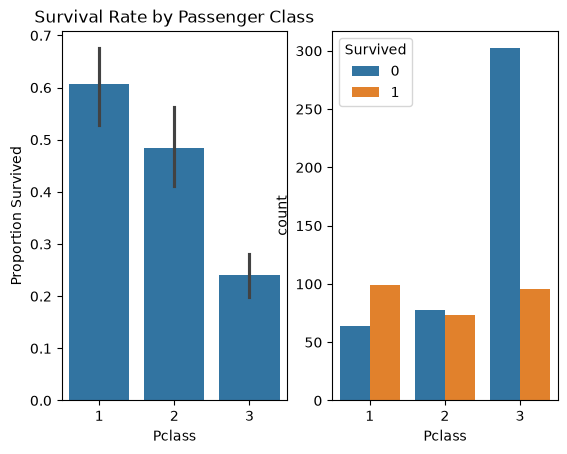

In [36]:
# Show the relevant statistics or visualization(s) to support your answer
fig, axes = plt.subplots(1, 2)
sns.barplot(
    data=data,
    x="Pclass",
    y="Survived",
    ax=axes[0]
)
axes[0].set_title("Survival Rate by Passenger Class")
axes[0].set_ylabel("Proportion Survived")

# Number of survivors and non-survivors in each class
sns.countplot(
    data=data,
    x="Pclass",
    hue="Survived",
    ax=axes[1]
)


plt.show()

# Question 2: Is survival related to Embarked?

Answer: Yes it does look like it. Maybe because some ports had more first-class passangers than others. 

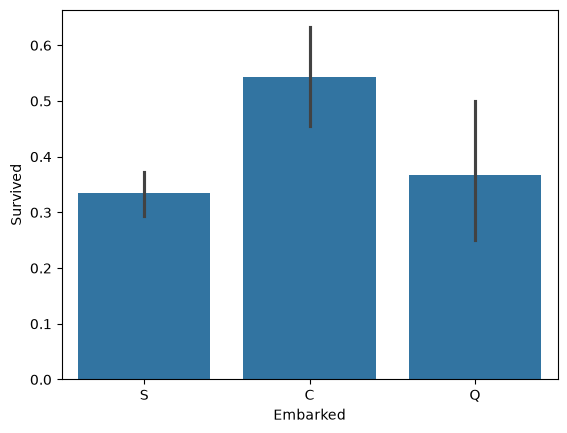

In [33]:
# Show the relevant statistics or visualization(s) to support your answer
sns.barplot(x="Embarked", y="Survived", data=data)
plt.show()

# Question 3: How is age related to survival?

Answer: Surprisingly not much correlation. There is however a very small correlation between lower age and survival. You can also see that most aged between 0-10 survived.

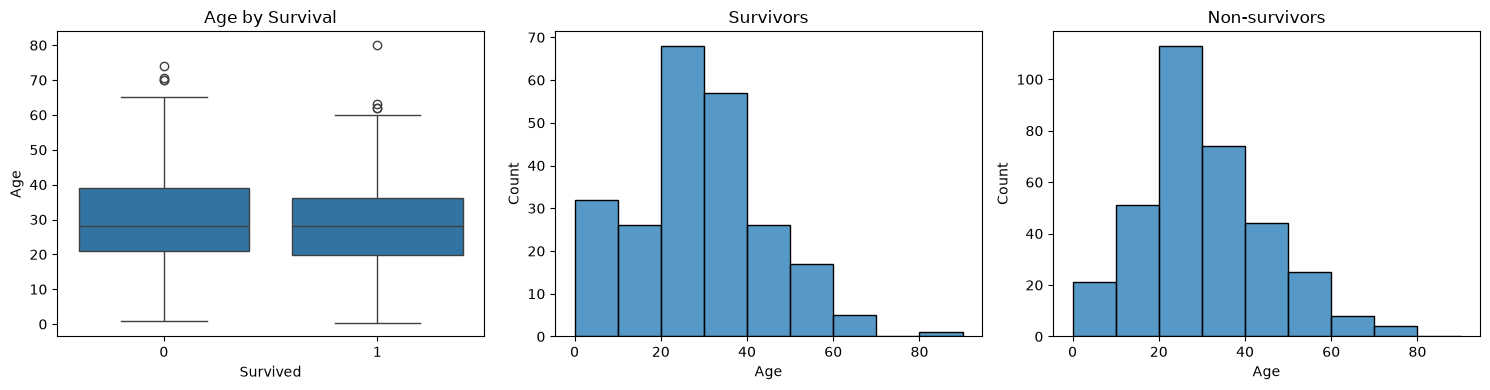

In [59]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(
    data=data,
    x="Survived",
    y="Age",
    ax=axs[0]
)
axs[0].set_title("Age by Survival")

sns.histplot(
    data=data[data["Survived"] == 1],
    x="Age",
    bins=range(0, 91, 10),
    ax=axs[1]
)
axs[1].set_title("Survivors")

sns.histplot(
    data=data[data["Survived"] == 0],
    x="Age",
    bins=range(0, 91, 10),
    ax=axs[2]
)
axs[2].set_title("Non-survivors")

plt.tight_layout()
plt.show()

# Question 4: Does family size somehow affect the survival rate?

Answer: Even though there is a slight correlation between class and #Family members, there is no concrete correlation between #Family members and survival rate. 

<Axes: xlabel='Survived', ylabel='FamilyMembers'>

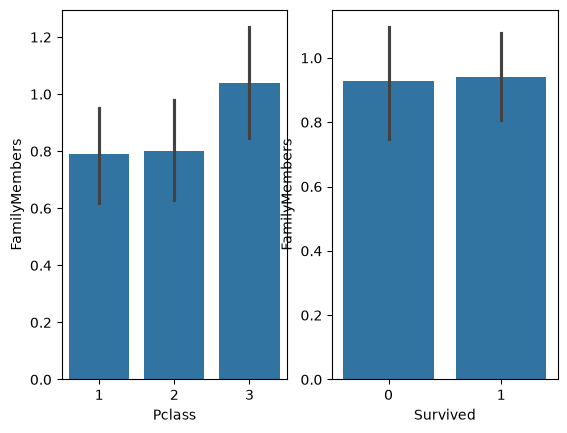

In [ ]:
# Show the relevant statistics or visualization(s) to support your answer
fig, axs = plt.subplots(1,2)
family_data = data.assign(FamilyMembers=data["SibSp"] + data["Parch"]) #created new DataFrame 
# with all data fram data, in addition to new data
sns.barplot(
    data=family_data,
    x="Pclass",
    y="FamilyMembers",
    ax=axs[0]
)
sns.barplot(
    data=family_data,
    x="Survived",
    y="FamilyMembers",
    ax=axs[1]
)

# Question 5: Some passengers with certain titles seemed to have more chance to survive. Is that true?

Answer: Women survived more than men, married women survived a bit more than unmarries women, master (young male) survived more than adult males.

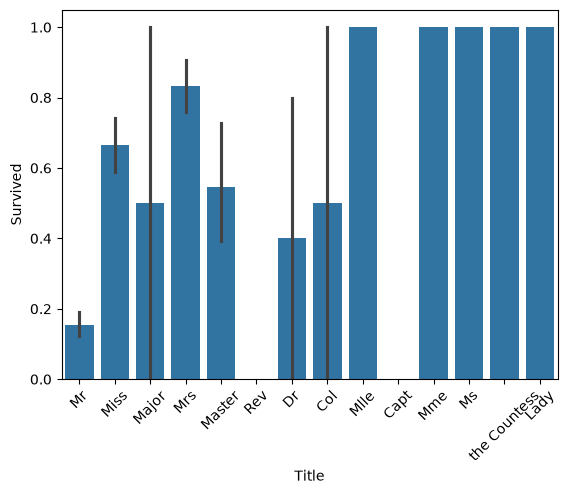

In [58]:
# Show the relevant statistics or visualization(s) to support your answer
# Exploring the names whether they include titles
data["Name"].head(20)
# There seems to be titles like Mr., Miss. etc. 

def extract_title(name):
    part_after_comma = name.split(",", 1)[1]
    title = part_after_comma.split(".", 1)[0]
    return title.strip()

data_titles = data.assign(
    Title=data["Name"].apply(extract_title)
)

sns.barplot(
    data=data_titles,
    x="Title",
    y="Survived"
)
plt.xticks(rotation=45)
plt.show()